In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [26]:
def lorentzian(x,c,gam,a,y0):
    return y0 + (2*a/np.pi)*gam/(4*(x-c)**2 + gam**2)

def ext_BW(freq, ydata, plot=False):
    
    ymin = np.min(ydata)
    ymax = np.max(ydata)

     #initial guess
    left_index = np.where(ydata > 0.5*(ymax+ymin)) [0][0]    #FWHM
    right_index = np.where(ydata > 0.5*(ymax+ymin))[0][-1]   #FWHM
    BW_g = freq[right_index] - freq[left_index]
    wc_g = freq[np.argmax(ydata)]
    a_g = 0.5*np.pi*(ymax-ymin)*BW_g
    y0_g = ymin


    res, cov = curve_fit(lorentzian,freq,ydata,[wc_g, BW_g, a_g, y0_g])

    
    f0, bw = res[0], res[1]
    f0_err, bw_err = np.sqrt(cov[0,0]), np.sqrt(cov[1,1])

    a, y0 = res[2], res[3]
    a_err, y0_err = np.sqrt(cov[2,2]), np.sqrt(cov[3,3])

    H = 2*a/(np.pi*bw)
    H_err = H*(a_err/a + bw_err/bw) 
    y_xc = H + y0
    y_xc_err = H_err + y0_err
    
    r = (y0 - y_xc)/(y0 + y_xc)
    r_err = r*(y0_err + y_xc_err)*(1/(-y0 + y_xc) + 1/(-y0 - y_xc))

    kint = bw/(1+r)
    kext = bw*r/(1+r)

    kint_err = kint*(bw_err/bw + r_err/(r+1))
    kext_err = bw_err + kint_err
    
    Qint = f0/kint
    Qext = f0/kext
    
    Qint_err = Qint*(f0_err/f0 + kint_err/kint)
    Qext_err = Qext*(f0_err/f0 + kext_err/kext)

    
        
    f0 = np.round(f0*1e-9,10)
    f0_err = np.round(f0_err*1e-9,10)
    bw = np.round(bw*1e-9,10)
    bw_err = np.round(bw_err*1e-9,10)
    kint = np.round(kint*1e-9,10)
    kext = np.round(kext*1e-9,10)
    kint_err = np.round(kint_err*1e-9,10)
    kext_err = np.round(kext_err*1e-9,10)
    
    if plot:
        plt.plot(freq*1e-9, ydata, label = "Data")
        plt.plot(freq*1e-9, lorentzian(freq, res[0], res[1], res[2], res[3]), c = 'r',label = "Fit")
        plt.xlabel("Frequency (GHz)")
        plt.ylabel("Measured ReS11")
        plt.grid()
        plt.legend()
        plt.show()
        print("Cavity Frequency = {0} GHz; Total Bandwidth = {1} MHz".format(f0, 1e3*bw))
        print("Internal Bandwidth = {0} MHz; External Bandwidth = {1} MHz".format(1e3*kint,1e3*kext))
        
    out1 = [(f0, f0_err), (1e3*kint, 1e3*kint_err), (1e3*kext, 1e3*kext_err)]
    out2 = [(Qint, Qint_err), (Qext,Qext_err)]
    
    return out1, out2 ,res, np.sqrt(np.diag(cov))


In [40]:
data = np.transpose(np.loadtxt(r'D:\Experiments\2023-11-17 2DRX08, Double Ring, New  Paramps Test\Double ring low temp response\C2\Cav_real_imag_0dBm.txt', dtype= str))
freq= [float(freq) for freq in data[0]]
ydata= [float(ydat) for ydat in data[1]]

freq = np.array(freq)
ydata = np.array(ydata)



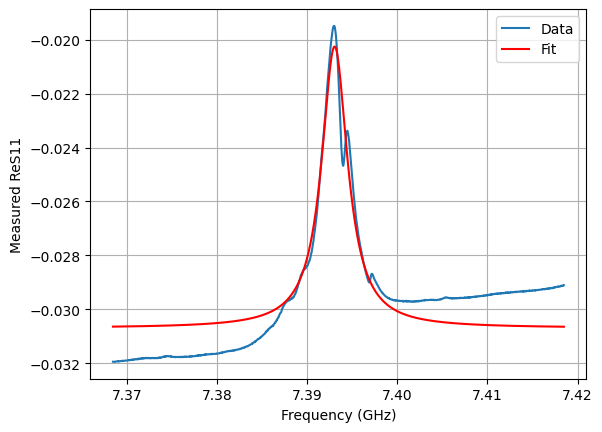

Cavity Frequency = 7.3930483624 GHz; Total Bandwidth = 3.5076867000000003 MHz
Internal Bandwidth = 2.9113439000000003 MHz; External Bandwidth = 0.5963429 MHz


In [41]:
meas_vals, q_vals, fit_param, fit_error = ext_BW(freq, ydata, plot=True)

In [122]:
#fit_param
fit_error

array([1.15582359e+02, 3.69630760e+02, 6.37827547e+01, 4.69143284e-05])

D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_-60.0_dBm.txt


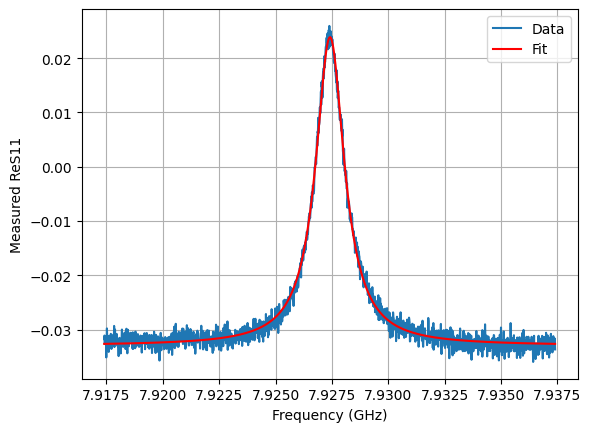

Cavity Frequency = 7.9274161175 GHz; Total Bandwidth = 1.5446541 MHz
Internal Bandwidth = 0.21336249999999998 MHz; External Bandwidth = 1.3312916000000001 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_-50.0_dBm.txt


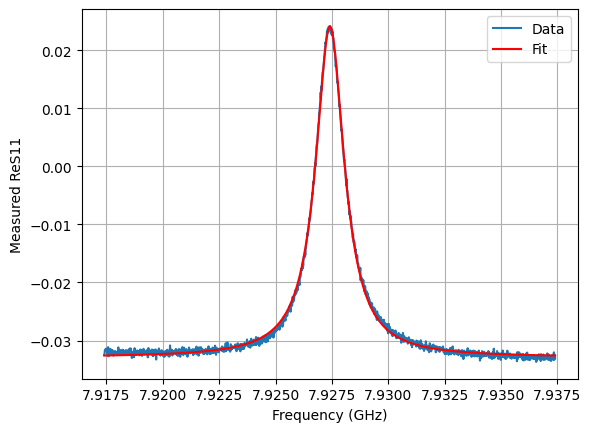

Cavity Frequency = 7.9274144565 GHz; Total Bandwidth = 1.5374131000000002 MHz
Internal Bandwidth = 0.2066807 MHz; External Bandwidth = 1.3307324 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_-40.0_dBm.txt


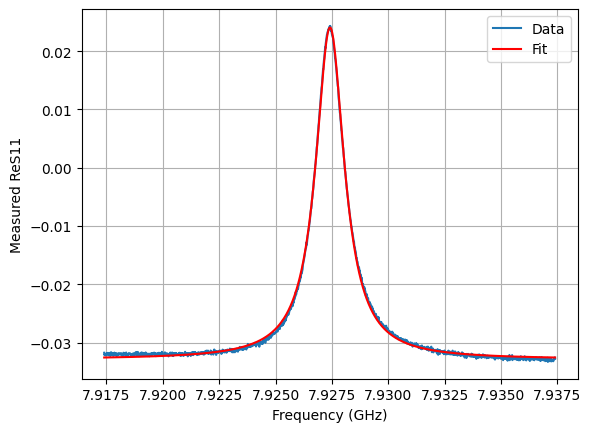

Cavity Frequency = 7.9274161057 GHz; Total Bandwidth = 1.5363205 MHz
Internal Bandwidth = 0.20612650000000002 MHz; External Bandwidth = 1.330194 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_-30.0_dBm.txt


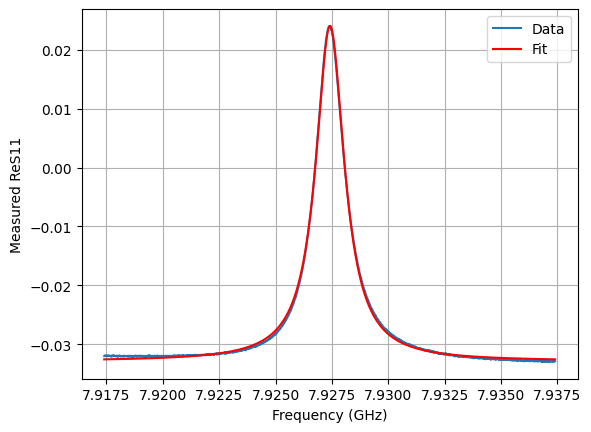

Cavity Frequency = 7.9274165923 GHz; Total Bandwidth = 1.537353 MHz
Internal Bandwidth = 0.2063527 MHz; External Bandwidth = 1.3310003000000001 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_-20.0_dBm.txt


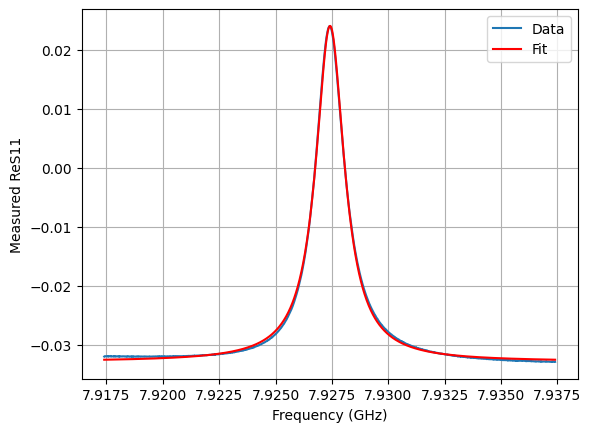

Cavity Frequency = 7.9274175418 GHz; Total Bandwidth = 1.5374576999999998 MHz
Internal Bandwidth = 0.20636100000000002 MHz; External Bandwidth = 1.3310967 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_-10.0_dBm.txt


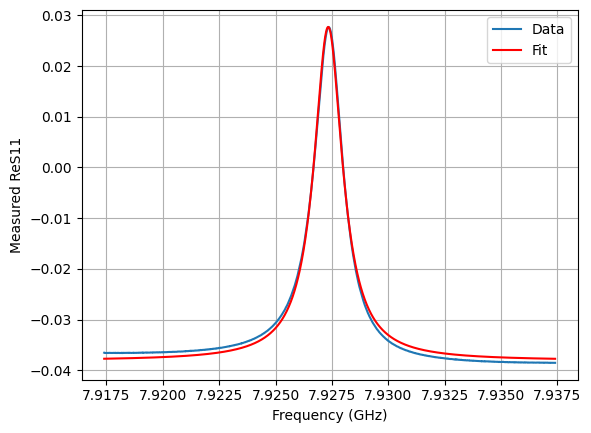

Cavity Frequency = 7.927335692 GHz; Total Bandwidth = 1.5373206 MHz
Internal Bandwidth = 0.2095683 MHz; External Bandwidth = 1.3277523 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_0.0_dBm.txt


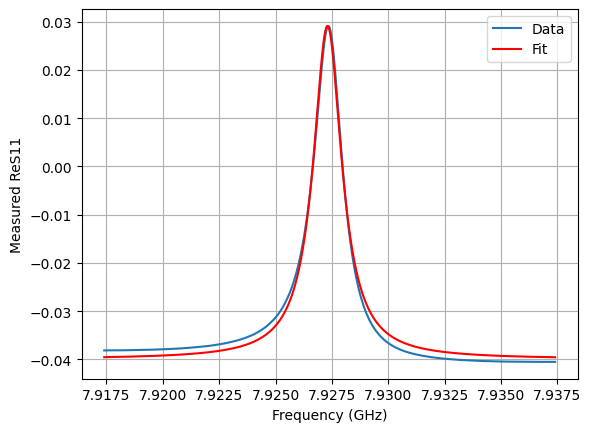

Cavity Frequency = 7.9273033813 GHz; Total Bandwidth = 1.5370171 MHz
Internal Bandwidth = 0.2081952 MHz; External Bandwidth = 1.328822 MHz
D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_10.0_dBm.txt


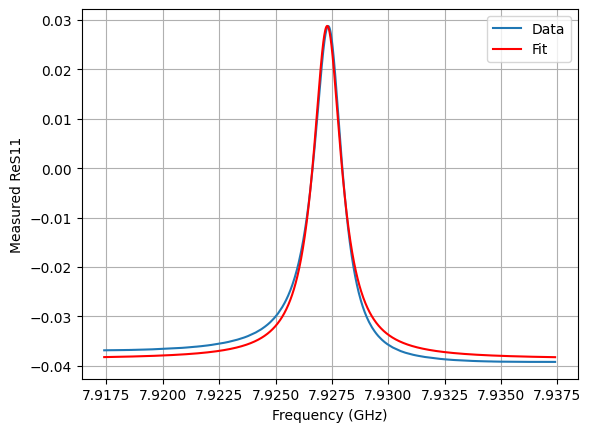

Cavity Frequency = 7.927291419 GHz; Total Bandwidth = 1.5213275 MHz
Internal Bandwidth = 0.1937103 MHz; External Bandwidth = 1.3276172 MHz


In [34]:
pmin, pmax = -60.0, 10.0
del_p = 10.0
p_vals = np.arange(pmin,pmax + del_p -1, del_p)

kint_list, kext_list = [], []
Qint_list, Qext_list = [], []
fit_param_list =[]
Q_with_pow_list=[]

for p in p_vals:
    
    filepath = rf'D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes\Real7p92_{p}_dBm.txt'
    print(filepath)
   
    data= np.transpose(np.loadtxt(filepath))
    freq=data[0]
    ydata=data[1]

    meas_vals, q_vals, fit_param, fit_error = ext_BW(freq, ydata, plot=True)
    
    fit_param_list.append([p, fit_param[0],fit_error[0], fit_param[1],fit_error[1],fit_param[2],fit_error[2],fit_param[3],fit_error[3]])
    Q_with_pow_list.append([p, meas_vals[0][0],q_vals[0][0], q_vals[0][1],q_vals[1][0], q_vals[1][1]])
    
    kint_list.append(meas_vals[1])
    kext_list.append(meas_vals[2])
    
    Qint_list.append(q_vals[0])
    Qext_list.append(q_vals[1])
# np.savetxt(r"D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes/7p92_Lorentian_fit_params_with_power.txt", fit_param_list, header="Power Freq Freq_err BW BW_err A A_err y0 y0_err")
# np.savetxt(r"D:\Experiments\2023-10-26 2DRX08-NewMount&Paramps, Double Ring\DoubleRingData\Modes/7p92_Q_with_power.txt", Q_with_pow_list, header="Power Freq Qint Qint_err Qext Qext_err")

In [17]:
fit_param_list

[[-80.0,
  7827012077.502512,
  41873.661283735986,
  1080986.092537169,
  129446.69875937658,
  42199.12263598161,
  3893.844293526858,
  -0.040292568259508096,
  0.0003339739334669964],
 [-70.0,
  7827105498.083809,
  15066.00725774848,
  1130119.9543886106,
  46772.47133225768,
  41775.54667726775,
  1337.4760490362726,
  -0.04043175635326829,
  0.00011218568870869952],
 [-60.0,
  7827072106.719307,
  5213.654512455841,
  1135172.4386407945,
  16192.870256277405,
  42592.946502772276,
  470.19169275680684,
  -0.04056584649819489,
  3.9351295345288356e-05],
 [-50.0,
  7827078809.079112,
  2869.1786058277753,
  1134196.2689735917,
  8910.55555841607,
  42322.58171414351,
  257.2910893963702,
  -0.040413374739957285,
  2.1541905267353232e-05],
 [-40.0,
  7827079921.084534,
  2496.7726574644835,
  1141106.2223412395,
  7758.530275310198,
  42549.53701078902,
  223.99665455878247,
  -0.04040978850563026,
  1.8698683958892404e-05],
 [-30.0,
  7827078665.460577,
  2392.3149315703095,
  114

[]

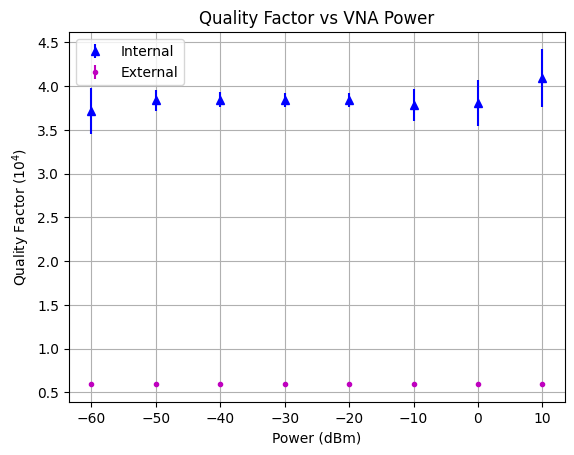

In [35]:
Qint_vals = np.array([Qint[0] for Qint in Qint_list])
Qint_err_vals = np.array([Qint[1] for Qint in Qint_list])
Qext_vals = np.array([Qext[0] for Qext in Qext_list])
Qext_err_vals = np.array([Qext[1] for Qext in Qext_list])

plt.errorbar(p_vals, 1e-4*Qint_vals, fmt="b^", label = "Internal", yerr=1e-4*Qint_err_vals, linestyle = None)
plt.errorbar(p_vals, 1e-4*Qext_vals, fmt="m.", label = "External", yerr=1e-4*Qext_err_vals, linestyle = None)
plt.xlabel("Power (dBm)")
plt.ylabel("Quality Factor ($10^4$)")
plt.title("Quality Factor vs VNA Power")
plt.grid()
plt.legend()
plt.plot()


[]

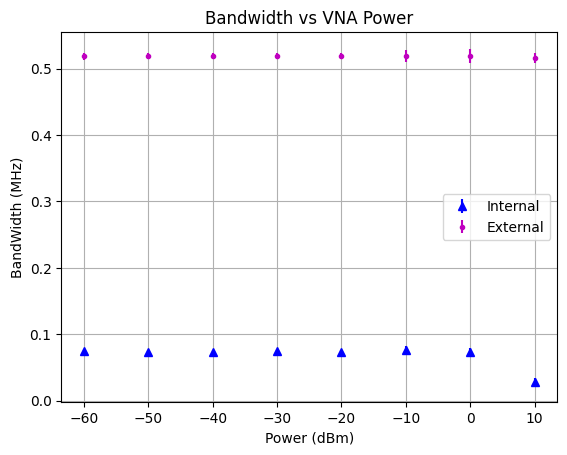

In [25]:
kint_vals = np.array([kint[0] for kint in kint_list])
kint_err_vals = np.array([kint[1] for kint in kint_list])
kext_vals = np.array([kext[0] for kext in kext_list])
kext_err_vals = np.array([kext[1] for kext in kext_list])

plt.errorbar(p_vals, kint_vals, fmt="b^", label = "Internal", yerr=kint_err_vals, linestyle = None)
plt.errorbar(p_vals, kext_vals, fmt="m.", label = "External", yerr=kext_err_vals, linestyle = None)
plt.xlabel("Power (dBm)")
plt.ylabel("BandWidth (MHz)")
plt.title("Bandwidth vs VNA Power")
plt.grid()
plt.legend()
plt.plot()

In [12]:
np.where(np.array([0,1,2,3,4,5,6])>2.5)[0]

array([3, 4, 5, 6], dtype=int64)

In [95]:
a=[[1,2,3],[4,5,6],[7,8,9]]

In [96]:
np.diag(a)

array([1, 5, 9])